In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeRegressor,plot_tree 
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.preprocessing import LabelEncoder
from tqdm import tqdm
import os
os.chdir("/home/pgcp-ai/MachineLearning/Datasets/")

In [2]:
boston = pd.read_csv("Boston.csv")
boston

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0


In [3]:
X, y = boston.drop('medv', axis = 1), boston["medv"]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3, random_state = 26)

In [23]:
depths = [1,2,3,4,5,6]
splits = []
scores = []
for d in tqdm(depths):
    dtc = DecisionTreeRegressor(max_depth=d,random_state=26)
    dtc.fit(X_train, y_train)
    y_pred = dtc.predict(X_test)
    scores.append([d,r2_score(y_test, y_pred)])
    
df_scores = pd.DataFrame(scores,columns=["Depth","R2 Score"])
df_scores.sort_values('R2 Score', ascending=False)

100%|████████████████████████████████████████████| 6/6 [00:00<00:00, 137.35it/s]


,Depth,R2 Score
5,6,0.848851
4,5,0.840638
3,4,0.837100
2,3,0.731566
1,2,0.649291
0,1,0.308362


In [25]:
depths = [1,2,3,4,5,6]
splits = [2,5,10,20,30]
scores = []
for s in tqdm(splits):
    dtc = DecisionTreeRegressor(min_samples_split=s,random_state=26)
    dtc.fit(X_train, y_train)
    y_pred = dtc.predict(X_test)
    scores.append([s,r2_score(y_test,y_pred)])
    
df_scores = pd.DataFrame(scores,columns=["Min Samples in each Node", "R2 Score"])
df_scores.sort_values('R2 Score', ascending = False)

100%|█████████████████████████████████████████████| 5/5 [00:00<00:00, 72.55it/s]


,Min Samples in each Node,R2 Score
3,20,0.819549
1,5,0.818846
4,30,0.818651
0,2,0.807207
2,10,0.803488


In [26]:
depths = [1,2,3,4,5,6]
splits = [2,5,10,20,30]
scores = []
for s in tqdm(splits):
    for d in depths:
        dtc = DecisionTreeRegressor(min_samples_split=s,random_state=26,max_depth=d)
        dtc.fit(X_train, y_train)
        y_pred = dtc.predict(X_test)
        scores.append([d,s,r2_score(y_test,y_pred)])
    
df_scores = pd.DataFrame(scores,columns=["Depth","Min Samples in each Node","R2 Score"])
df_scores.sort_values('R2 Score', ascending = False)

100%|█████████████████████████████████████████████| 5/5 [00:00<00:00, 29.56it/s]


,Depth,Min Samples in each Node,R2 Score
5,6,2,0.848851
17,6,10,0.844417
11,6,5,0.843515
10,5,5,0.840638
4,5,2,0.840638
29,6,30,0.840594
16,5,10,0.839735
27,4,30,0.839551
23,6,20,0.837940
21,4,20,0.837100


In [22]:
depths = [1,2,3,4,5,6]
splits = [1,5,8,10,20]
scores = []
for s in tqdm(splits):
    dtc = DecisionTreeRegressor(min_samples_leaf=s,random_state=26)
    dtc.fit(X_train, y_train)
    y_pred = dtc.predict(X_test)
    scores.append([s,r2_score(y_test,y_pred)])
    
df_scores = pd.DataFrame(scores,columns=["Min Leaves in each Node","R2 Score"])
df_scores.sort_values("R2 Score", ascending = False)

100%|████████████████████████████████████████████| 5/5 [00:00<00:00, 104.49it/s]


,Min Leaves in each Node,R2 Score
0,1,0.807207
3,10,0.791232
2,8,0.789549
4,20,0.743535
1,5,0.710788


In [7]:
depths_old = np.arange(1,7)
splits_old = np.arange(2,25)
leaves_old = np.arange(1,25)

depths = [1,2,3,5,None]
splits = [2,4,8,10,20,30,50,100]
leaves  = [1,4,8,10,20,30,45,46,50,100]

scores = []
for d in tqdm(depths):
    for s in splits:
        for l in leaves:     
            dtc = DecisionTreeRegressor(min_samples_split=s,random_state=26,max_depth=d,min_samples_leaf=l)
            dtc.fit(X_train, y_train)
            y_pred = dtc.predict(X_test)
            scores.append([d,s,l,r2_score(y_test, y_pred)])
df_scores = pd.DataFrame(scores,columns=["Depth","Min Samples in each Node to Split",'Min Samples in each Leaf Node',"R2 Score"])
df_scores.sort_values('R2 Score', ascending = False)

100%|█████████████████████████████████████████████| 5/5 [00:01<00:00,  2.86it/s]


,Depth,Min Samples in each Node to Split,Min Samples in each Leaf Node,R2 Score
240,5.0,2,1,0.840638
250,5.0,4,1,0.840638
260,5.0,8,1,0.839735
270,5.0,10,1,0.839735
290,5.0,30,1,0.835667
...,...,...,...,...
56,1.0,30,45,0.308362
57,1.0,30,46,0.308362
58,1.0,30,50,0.308362
59,1.0,30,100,0.308362


In [8]:
bm = DecisionTreeRegressor(random_state=26, max_depth = 5, min_samples_split=2, min_samples_leaf=1)
bm.fit(X, y)

DecisionTreeRegressor(max_depth=5, random_state=26)

In [9]:
list(X.columns)

['crim',
 'zn',
 'indus',
 'chas',
 'nox',
 'rm',
 'age',
 'dis',
 'rad',
 'tax',
 'ptratio',
 'black',
 'lstat']

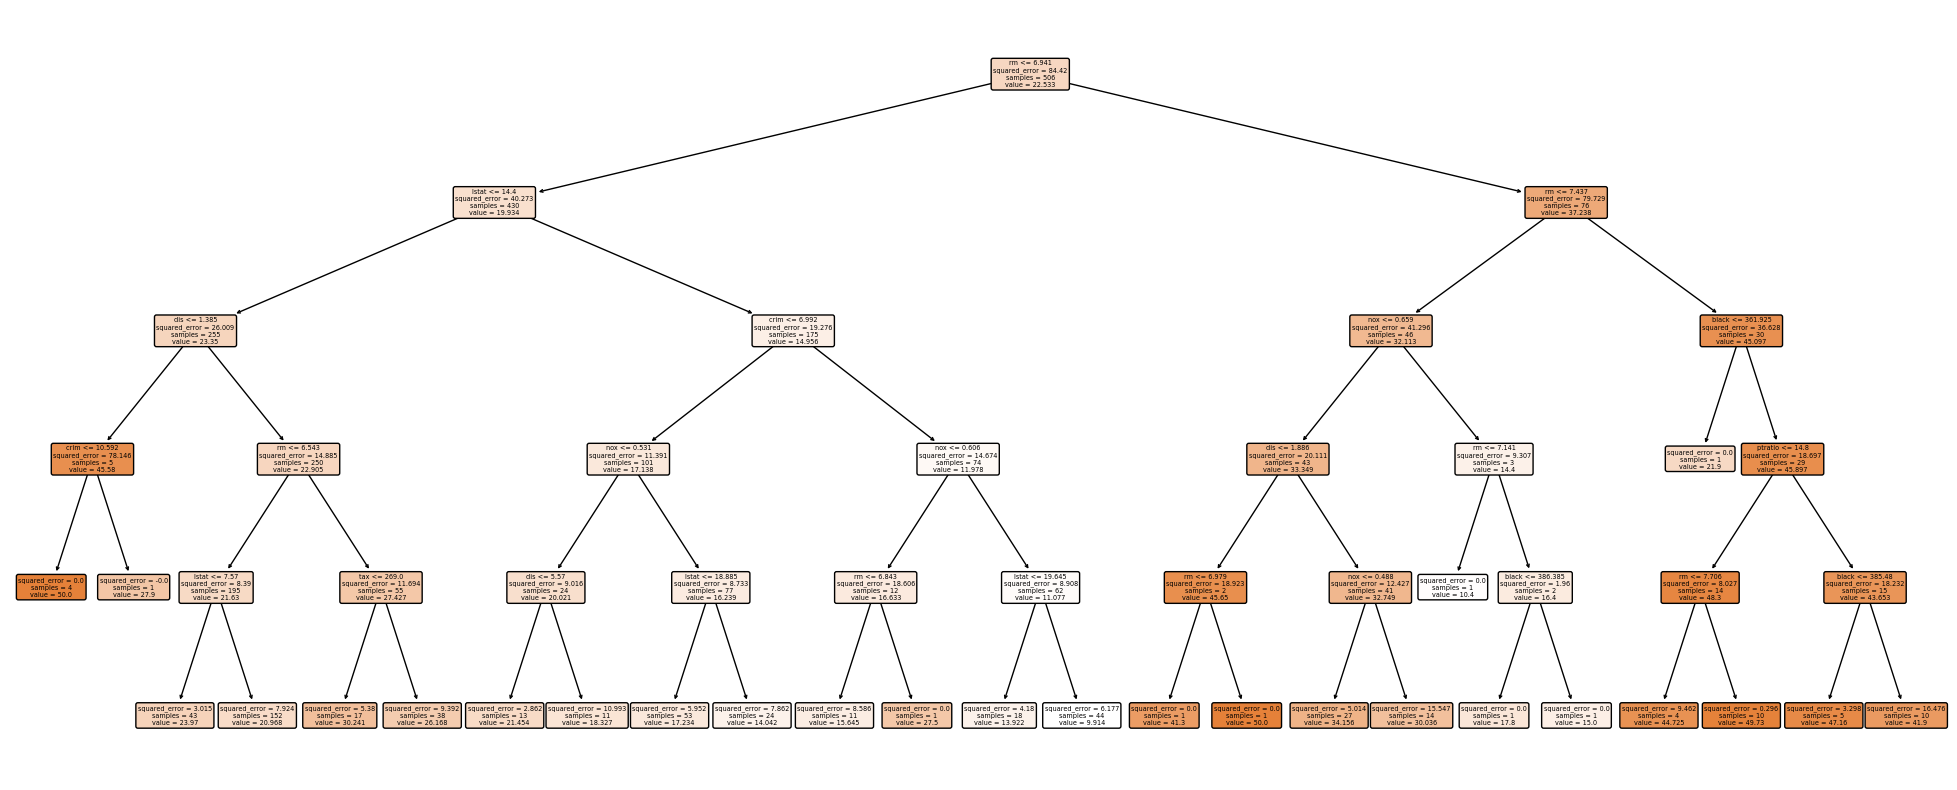

In [11]:
plt.figure(figsize = (25,10))
plot_tree(bm,filled=True, rounded = True,feature_names=list(X.columns))
plt.show()

In [12]:
bm.feature_importances_

array([0.03891305, 0.        , 0.        , 0.        , 0.04420959,
       0.61405161, 0.        , 0.07377308, 0.        , 0.00496307,
       0.00398298, 0.0166293 , 0.20347732])

In [14]:
df_imp = pd.DataFrame({'feature':X.columns, 'Importance': bm.feature_importances_})
df_imp = df_imp.sort_values("Importance")

In [17]:
df_imp = df_imp.sort_values("Importance")
df_imp

,feature,Importance
1,zn,0.000000
2,indus,0.000000
3,chas,0.000000
6,age,0.000000
8,rad,0.000000
10,ptratio,0.003983
9,tax,0.004963
11,black,0.016629
0,crim,0.038913
4,nox,0.044210


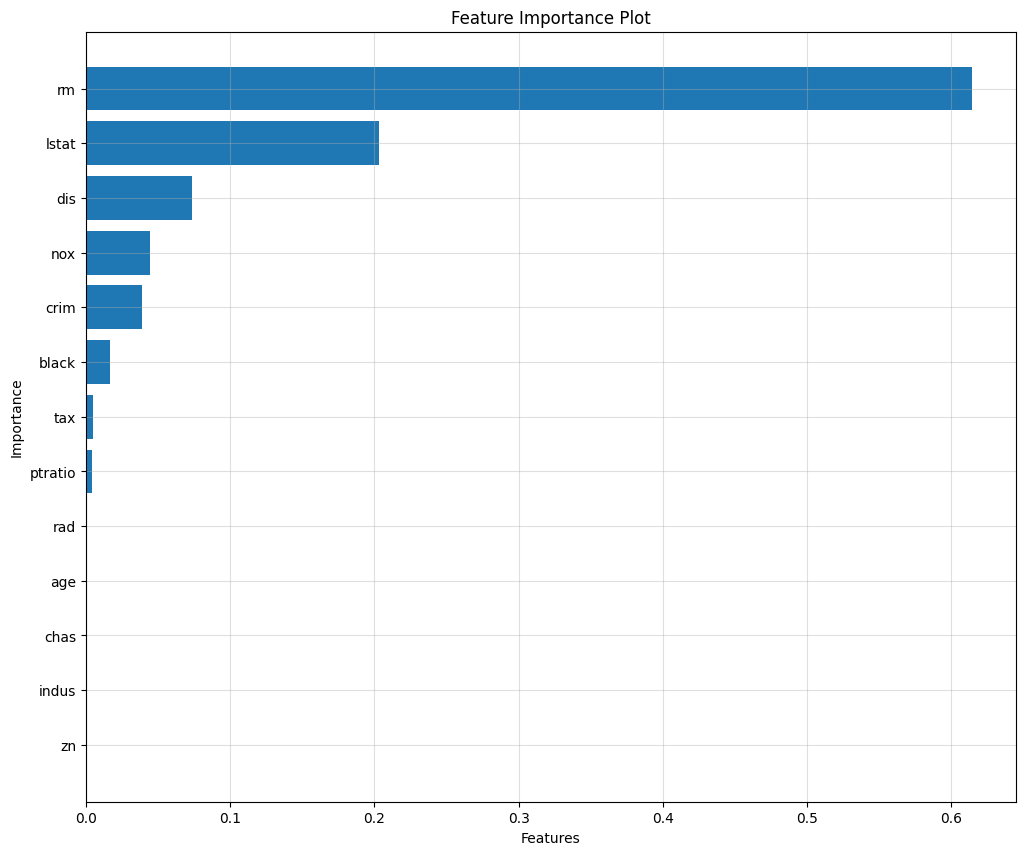

In [15]:
plt.figure(figsize=(12,10))
plt.barh(df_imp['feature'], df_imp['Importance'])
plt.title('Feature Importance Plot')
plt.xlabel('Features')    
plt.ylabel('Importance')
# plt.xticks(rotation=45)
plt.grid(True,alpha=0.4)
plt.show()

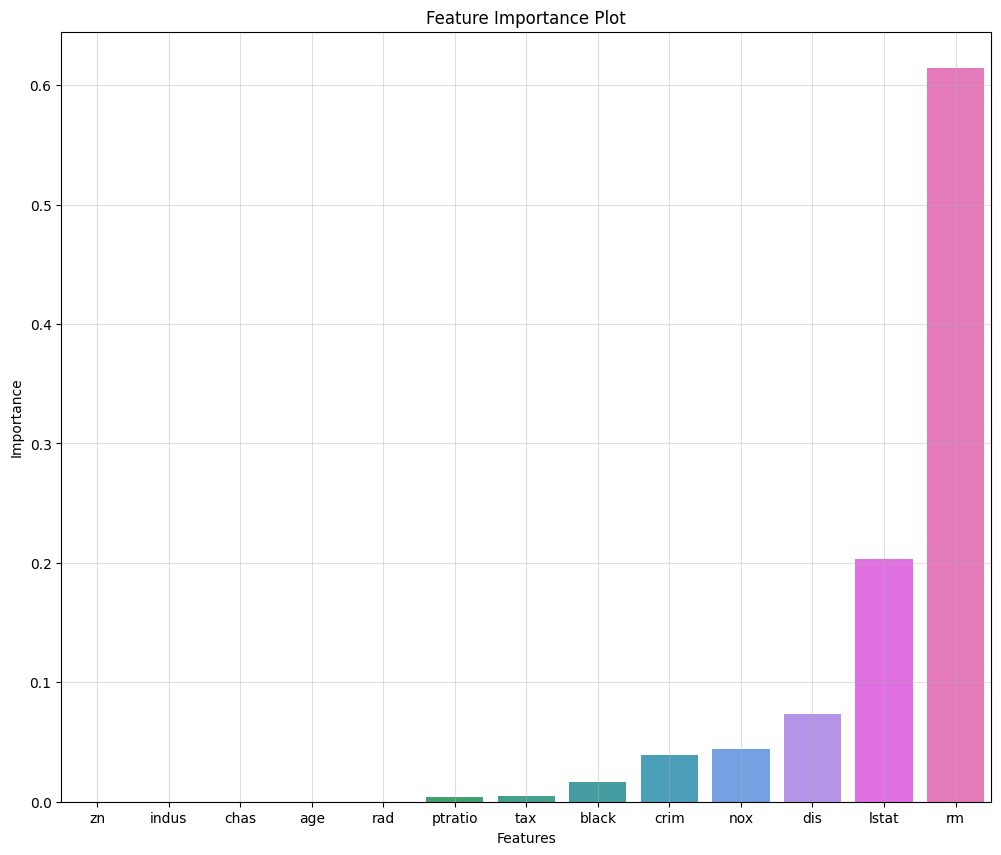

In [16]:
plt.figure(figsize=(12,10))
sns.barplot(data = df_imp,x='feature',y='Importance',hue='feature')
plt.title('Feature Importance Plot')
plt.xlabel('Features')    
plt.ylabel('Importance')
plt.grid(True,alpha=0.4)
plt.show()